In [1]:
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
x = np.sort(10 * np.random.rand(20) / 2)
y = 10 * np.random.rand(20) / 2

In [3]:
A = np.vstack([x, np.ones(len(x))]).T

# Solve using least squares

m, c = np.linalg.lstsq(A, y, rcond=None)[0]

print(f"Slope: {m}, Intercept: {c}")

Slope: -0.7248870750957775, Intercept: 4.6599799613275374


In [4]:
# Step 2: Polynomial fitting using NumPy's polyfit
# Fit a 2nd degree polynomial to the data
degree = 3 # Degree of the polynomial
coefficients = np.polyfit(x, y, degree)
print("Polynomial Coefficients: ", coefficients)

polynomial = np.poly1d(coefficients)

Polynomial Coefficients:  [-0.27683966  1.90776734 -3.89275972  5.09466891]


         3         2
-0.2768 x + 1.908 x - 3.893 x + 5.095


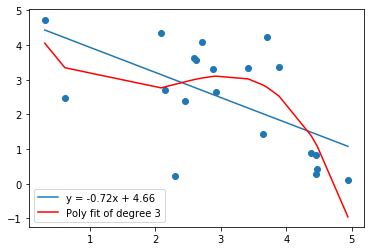

In [10]:
plt.scatter(x, y)
x_line = np.linspace(min(x), max(x), 20)

y_line = m * x_line + c
y_pred = polynomial(x)


plt.plot(x_line, y_line ,label=f'y = {m:.2f}x + {c:.2f}')
plt.plot(x, y_pred, color='red', label=f'Poly fit of degree {degree}')
print(polynomial)


plt.legend()
plt.show()



In [11]:
mse_linear = np.mean((y - y_line)**2)
ss_total = np.sum((y - np.mean(y))**2)
ss_res_linear = np.sum((y - y_line)**2)
r2_linear = 1 - (ss_res_linear / ss_total)

mse_poly = np.mean((y - y_pred)**2)
ss_res_poly = np.sum((y - y_pred)**2)
r2_poly = 1 - (ss_res_poly / ss_total)

print("Linear Fit:")
print(f"MSE = {mse_linear:.4f}, R^2 = {r2_linear:.4f}")

print("\nPolynomial Fit:")
print(f"MSE = {mse_poly:.4f}, R^2 = {r2_poly:.4f}")

print("\nModel Comparison:")

if mse_poly < mse_linear and r2_poly > r2_linear:
    print("Polynomial fit is better.")
elif mse_linear < mse_poly and r2_linear > r2_poly:
    print("Linear least squares fit is better.")
else:
    print("Can not determine: one metric favors each model.")

Linear Fit:
MSE = 1.6141, R^2 = 0.2848

Polynomial Fit:
MSE = 1.0352, R^2 = 0.5413

Model Comparison:
Polynomial fit is better.
